In [13]:
import sys
print(sys.executable)

d:\B-Tech\7th Sem_BTech\ADS_Lab\Assignment_01\tfenv\Scripts\python.exe


In [14]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [15]:
# Load Dataset
df = pd.read_csv("Housing.csv")

# Display first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [16]:
# Shape of dataset
print("Shape :", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Information
print("\nDataset Information:")
df.info()

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

Shape : (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishin

In [17]:
print(df.dtypes)

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


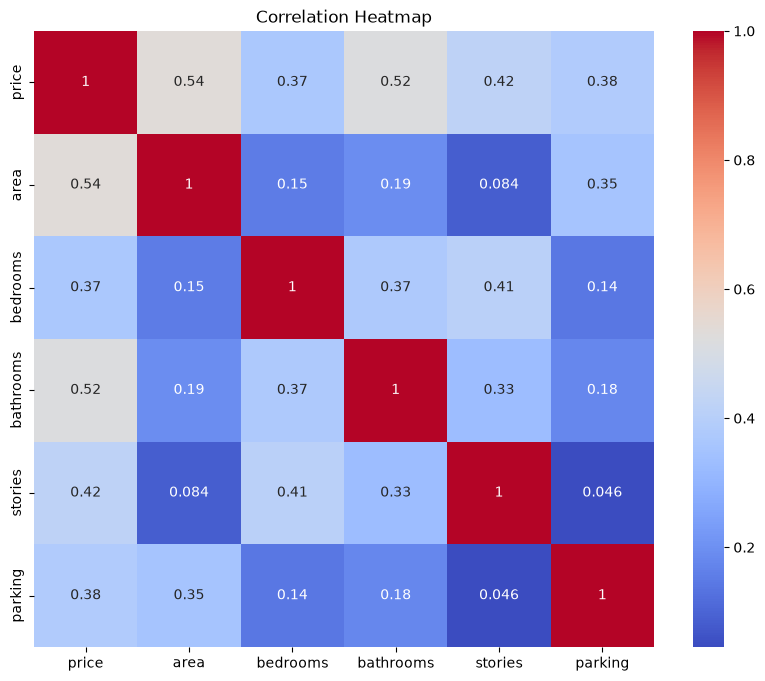

In [18]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

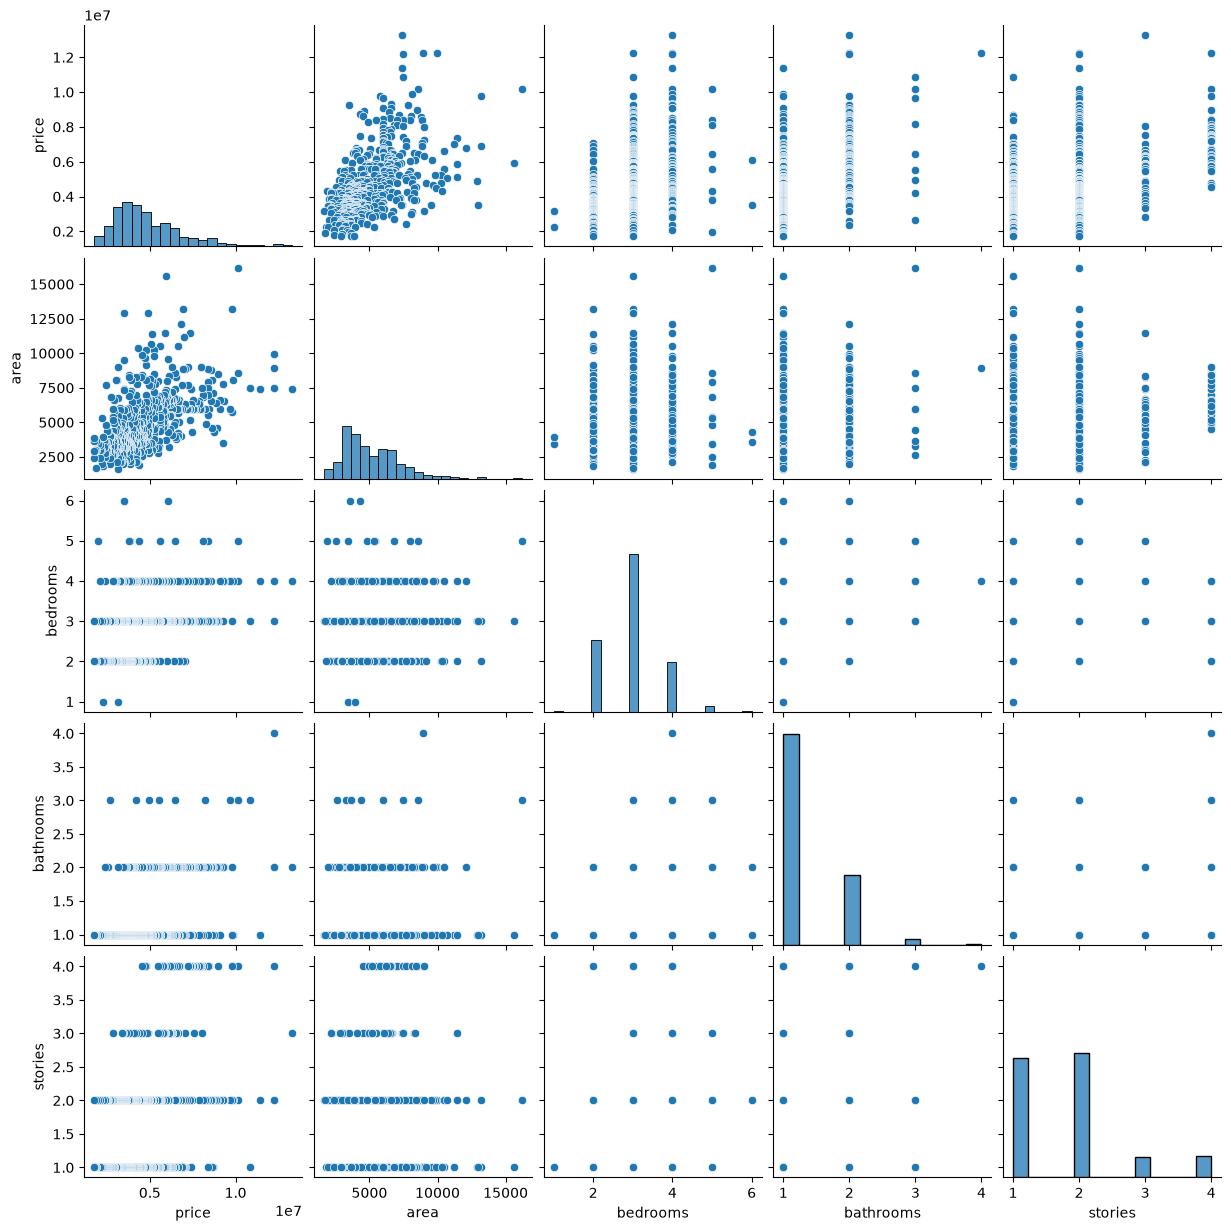

In [19]:
sns.pairplot(df[['price','area','bedrooms','bathrooms','stories']])
plt.show()

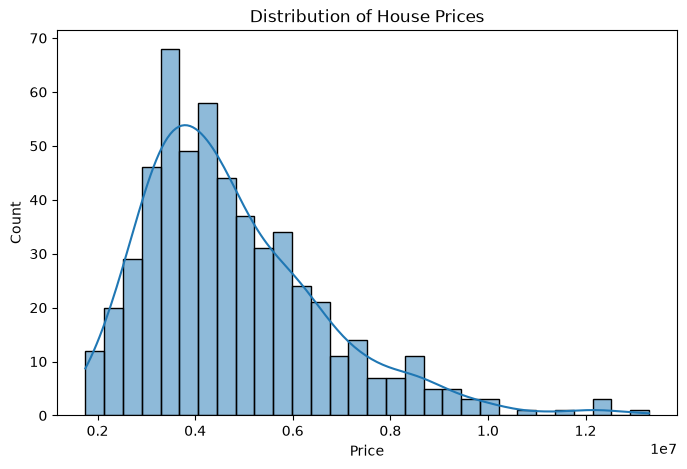

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

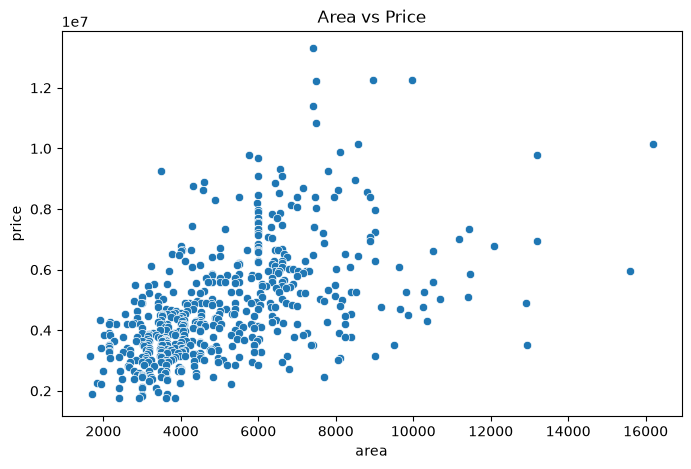

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='area', y='price', data=df)

plt.title("Area vs Price")

plt.show()

In [22]:
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Display first 5 rows after encoding
df.head()

C:\Users\siddh\AppData\Local\Temp\ipykernel_6160\3967287033.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [23]:
# Features and Target

X = df.drop("price", axis=1)
y = df["price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (545, 12)
Target Shape : (545,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (436, 12)
Testing Data : (109, 12)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
print(X_train[:5])

[[ 0.38416819  0.05527092  1.53917323  2.58764353  0.40715525 -0.46677307
  -0.74642003 -0.23052136  1.50124327  0.36795665 -0.55262032 -1.40940148]
 [ 0.9291807   0.05527092  1.53917323 -0.91249891  0.40715525 -0.46677307
   1.33972825 -0.23052136  1.50124327  2.70998729 -0.55262032 -0.07931697]
 [-0.60775457 -1.28351359 -0.5579503  -0.91249891  0.40715525 -0.46677307
   1.33972825 -0.23052136  1.50124327  1.53897197 -0.55262032 -1.40940148]
 [-1.15549214  0.05527092 -0.5579503   0.25421524  0.40715525 -0.46677307
   1.33972825 -0.23052136 -0.66611456 -0.80305867  1.80956067  1.25076755]
 [-0.63773026  0.05527092 -0.5579503   0.25421524  0.40715525 -0.46677307
  -0.74642003 -0.23052136 -0.66611456 -0.80305867 -0.55262032  1.25076755]]


In [27]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (436, 12)
X_test : (109, 12)
y_train : (436,)
y_test : (109,)


In [28]:
# Import Required Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create ANN Model
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer (Regression)
model.add(Dense(1, activation='linear'))

d:\B-Tech\7th Sem_BTech\ADS_Lab\Assignment_01\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 25349387714560.0000 - mae: 4727421.5000 - val_loss: 24781596393472.0000 - val_mae: 4623896.5000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349383520256.0000 - mae: 4727422.0000 - val_loss: 24781590102016.0000 - val_mae: 4623896.5000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349373034496.0000 - mae: 4727421.0000 - val_loss: 24781577519104.0000 - val_mae: 4623895.0000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25349360451584.0000 - mae: 4727419.0000 - val_loss: 24781558644736.0000 - val_mae: 4623893.5000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349335285760.0000 - mae: 4727416.0000 - val_loss: 24781531381760.0000 - val_mae: 4623890.0000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349299634176.0000 - mae: 4727413.0000 - val_loss: 24781483147264.0000 - val_mae: 4623885.5000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2534924510

In [32]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20055169433600.0000 - mae: 4147622.7500 
Test Loss (MSE): 20055169433600.0
Test MAE: 4147622.75


In [33]:
y_pred = model.predict(X_test)

print(y_pred[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[2.5585541e+05]
 [2.0040624e+06]
 [3.3709528e+05]
 [3.5324262e+05]
 [2.5565256e+05]
 [2.8822250e+05]
 [1.3431506e+06]
 [2.1173990e+06]
 [2.2408141e+05]
 [2.8779484e+05]]


In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("R2 Score :", r2)

RMSE : 4478299.837393651
R2 Score : -2.9677295684814453


In [35]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.flatten()
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,2.558554e+05
1,6650000,2.004062e+06
2,3710000,3.370953e+05
3,6440000,3.532426e+05
4,2800000,2.556526e+05
5,4900000,2.882225e+05
6,5250000,1.343151e+06
7,4543000,2.117399e+06
8,2450000,2.240814e+05
9,3353000,2.877948e+05


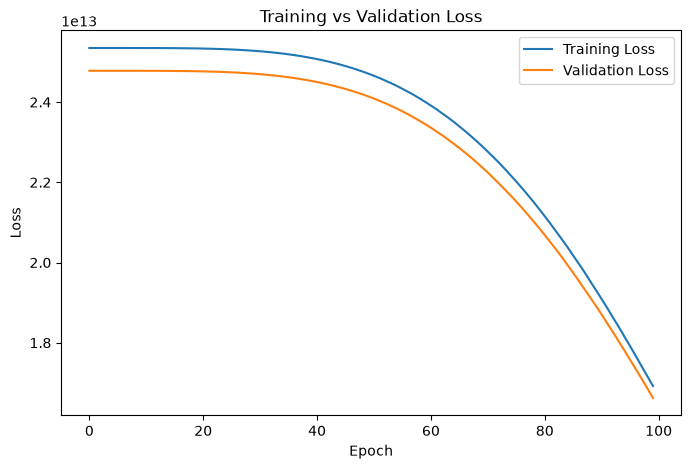

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

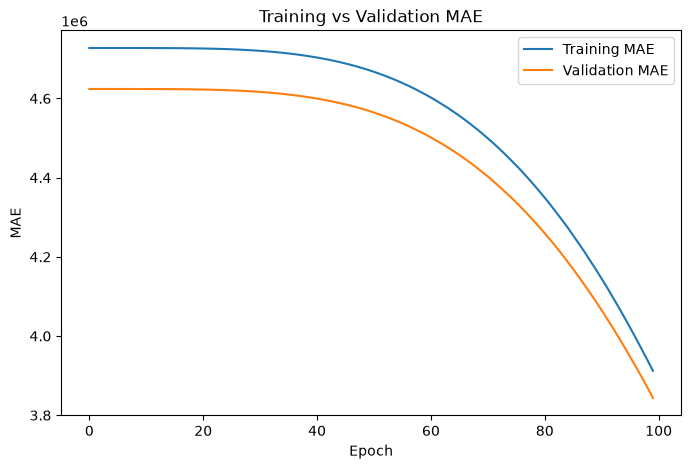

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()

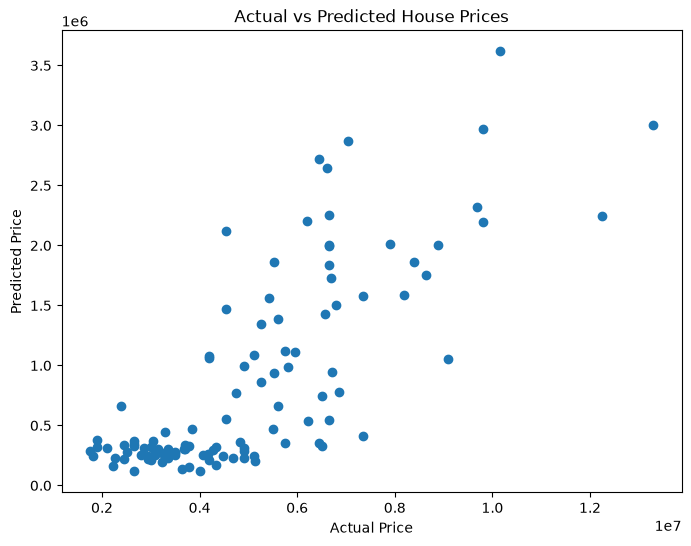

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [39]:
sample = np.array([[7420,4,2,3,1,0,1,0,1,2,1,2]])

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("Predicted House Price :", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted House Price : 2.7167695e+06


d:\B-Tech\7th Sem_BTech\ADS_Lab\Assignment_01\tfenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [40]:
model.save("house_price_ann_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [41]:
from tensorflow.keras.models import load_model

loaded_model = load_model("house_price_ann_model.keras")

prediction = loaded_model.predict(sample)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[2.7167695e+06]]
